# Question 1
Write a script that creates a data structure (list, dictionary, array, etc.) that
represents a deck of playing cards, and shuffles the deck randomly, creating 4 hands
of 13 cards each.

In [2]:
import random
import pprint as pp
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [5]:
class PlayingCards:
    
    def __init__(self):
        self.suits = ["S","C","H","D"]
        self.ranks = list(range(1,14))
        self.players = None
        self.deck = None
        self.fresh_deck()
        
    def fresh_deck(self):
        """create a fresh deck of 52 cards"""
        deck = []
        for suit in self.suits:
            for rank in self.ranks:
                deck.append((suit,rank))                
        self.deck = deck 
        
    def shuffle(self):
        random.shuffle(self.deck)
        
    def draw_13_cards(self):
        """draw 13 cards from existing deck without replacement"""
        cards = random.sample(self.deck,13)
        for card in cards:
            self.deck.remove(card)
        return cards    
            
    def deal_4_hands(self):
        """deal 4 hands of 13 cards each"""
        players = {}
        for player_index in range(4):
            hand = self.draw_13_cards()
            players[player_index]= hand
        self.players = players 
        
    def deal_4_hands_fast(self):
        """deal 4 hands of 13 cards each; slightly more efficient but less readable"""
        players = {}
        self.shuffle()
        for i in range(4):
            players[i] = self.deck[i*13:i*13+13]
        self.deck = []    
        self.players = players

In [6]:
# deal_4_hands()
cards = PlayingCards()
cards.fresh_deck()
cards.deal_4_hands()
pp.pprint(cards.players)

{0: [('S', 8),
     ('D', 2),
     ('S', 4),
     ('D', 10),
     ('H', 3),
     ('D', 5),
     ('S', 7),
     ('C', 12),
     ('H', 10),
     ('H', 4),
     ('S', 10),
     ('C', 7),
     ('D', 12)],
 1: [('S', 5),
     ('D', 3),
     ('S', 12),
     ('S', 3),
     ('D', 7),
     ('C', 1),
     ('C', 8),
     ('D', 6),
     ('S', 9),
     ('H', 9),
     ('C', 10),
     ('S', 1),
     ('D', 9)],
 2: [('D', 1),
     ('C', 4),
     ('H', 12),
     ('H', 7),
     ('S', 6),
     ('D', 4),
     ('S', 11),
     ('H', 2),
     ('H', 6),
     ('H', 13),
     ('H', 1),
     ('C', 5),
     ('D', 13)],
 3: [('C', 13),
     ('H', 11),
     ('D', 8),
     ('C', 11),
     ('S', 2),
     ('D', 11),
     ('C', 2),
     ('C', 9),
     ('C', 3),
     ('H', 8),
     ('H', 5),
     ('C', 6),
     ('S', 13)]}


In [7]:
# deal_4_hands_fast()
cards = PlayingCards()
cards.fresh_deck()
cards.deal_4_hands_fast()
pp.pprint(cards.players)

{0: [('H', 3),
     ('H', 7),
     ('S', 12),
     ('S', 6),
     ('S', 3),
     ('H', 13),
     ('D', 8),
     ('D', 9),
     ('C', 8),
     ('H', 11),
     ('C', 2),
     ('S', 1),
     ('H', 8)],
 1: [('C', 10),
     ('D', 5),
     ('D', 10),
     ('C', 9),
     ('D', 13),
     ('D', 7),
     ('H', 2),
     ('C', 12),
     ('S', 4),
     ('D', 11),
     ('C', 4),
     ('C', 3),
     ('C', 1)],
 2: [('C', 11),
     ('D', 4),
     ('C', 7),
     ('H', 4),
     ('S', 8),
     ('C', 5),
     ('H', 9),
     ('C', 6),
     ('H', 12),
     ('S', 13),
     ('S', 7),
     ('S', 2),
     ('H', 10)],
 3: [('S', 9),
     ('D', 2),
     ('D', 3),
     ('H', 5),
     ('D', 6),
     ('S', 11),
     ('H', 6),
     ('S', 5),
     ('C', 13),
     ('S', 10),
     ('D', 1),
     ('H', 1),
     ('D', 12)]}


# Question 2
This is a government website with a specific type of property listing:
https://app1.sla.gov.sg/spio​ . Pick one of the listings. Use Python’s requests library to
get the html text, and load the data in the “About this property” table into a pandas
Dataframe.

In [9]:
import requests
import warnings
import pandas as pd
from bs4 import BeautifulSoup
pd.set_option("display.max_rows", 30,'display.max_colwidth', -1)
warnings.filterwarnings("ignore", category=FutureWarning)

We will scrape the property details of the following listings, a bangalow at [20 malcolm road](https://app1.sla.gov.sg/SPIO/PropertyDetails/11RB80).

In [ ]:
url = "https://app1.sla.gov.sg/SPIO/PropertyDetails/11RB80"
res = requests.get(url)
soup = BeautifulSoup(res.content, 'html.parser')

table = soup.table
tds = table.find_all("td")

keys = []
values = []
for idx,td in enumerate(tds):
    if idx%2 ==0:
        keys.append(td.text)
    else:
        values.append(td.text.strip())    

dict_ = {key: value for key, value in zip(keys, values)}
df = pd.DataFrame.from_dict(dict_,orient='index')
df.columns= ["About this property"]

### Property Details of 20 Malcolm Road

In [10]:
df

,About this property
Property Status,Available Now
Property Location,Core central region
Property Type,Bungalow
Land Area (sqft),"31,441.64"
GFA (sqft),"5,106.22"
Tenure,2 years lease
Amenities,"Surrounded by schools such as CJC, SJI and SCGS"
Mode of Transaction,Rent Direct
District,11 & 21 Central West
No. of Storeys,2


# Question 3
Copy the following line of code into a script (or jupyter notebook) to create some
sample data for K-means clustering:

a. 
```
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=100, random_state=29, centers=3,
cluster_std=1.5)
X = map(lambda x: (x[0][0], x[0][1]), zip(X, color))
```
b. 

Cluster the data using K-means, with 3 clusters. Store the resulting clusters,
together with the data, in a dataframe and display the output. Do not forget
any pre-processing you’d have to carry out on the data!

In [11]:
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=100, random_state=29, centers=3,
cluster_std=1.5)
X.shape

(100, 2)

####  Note that  `color` in `zip(X, color)` is  not provided, and this line of code is not executed.

In [12]:
# X = map(lambda x: (x[0][0], x[0][1]), zip(X, color))

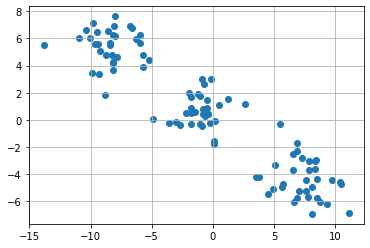

In [14]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1])
plt.grid()
plt.show()

## Preprocessing

1. Since X is generated from a sklearn blob, it does not have any NA values. 
2. Since k-means is a distance-based method, we will use `StandardScaler` to standardized X so that each of  X's features have zero mean and standard deviation of 1. In this case, looking at the plot below, using `StandardScaler` did not make any difference as all three clusters were generated from a normal distribution with standard deviation of 1.5 from `sklearn.datasets.make_blobs`.

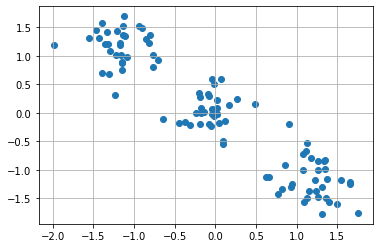

In [15]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.grid()
plt.show()

### Run Kmeans

In [16]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, 
            init='random', 
            n_init=10,
            max_iter=300, 
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X_scaled)

### Visualize cluster centriods

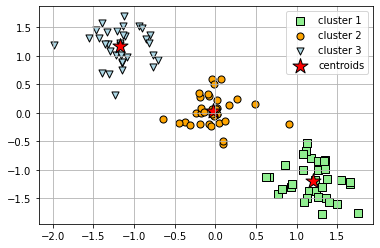

In [17]:
plt.scatter(X_scaled[y_km == 0, 0],
            X_scaled[y_km == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='cluster 1')

plt.scatter(X_scaled[y_km == 1, 0],
            X_scaled[y_km == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='cluster 2')

plt.scatter(X_scaled[y_km == 2, 0],
            X_scaled[y_km == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='cluster 3')

plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250, marker='*',
            c='red', edgecolor='black',
            label='centroids')

plt.legend(scatterpoints=1)
plt.grid()
plt.show()

### Stored in dataframe

Stored cluster_label `y_km` and `X` in a dataframe

In [18]:
data = {"X1":X[:,0],"X2":X[:,1],"Cluster": y_km} 
pd.DataFrame(data)

,X1,X2,Cluster
0,7.081642,-5.248171,0
1,-3.036735,-0.129646,1
2,5.117565,-3.323573,0
3,-1.807058,-0.335986,1
4,4.519789,-5.469635,0
...,...,...,...
95,11.101916,-6.830828,0
96,-8.260403,4.751107,2
97,-5.712878,3.899053,2
98,3.568490,-4.192956,0


# Question 4
Assuming you’re speaking to an individual who just picked up data science – explain
to him (in your own words) in simple terms what is a random forest, and the
difference from a bagged tree.


**Bagging** is the combination of two ideas, bootstrapping and aggregation. Bootstrapping means randomly sampling observations from an original training data set, with replacement, to create new training data sets. Aggregation means averaging the predictions of multiple trees to get out final prediction.

First, lets look into **bootstrapping**. Say you have 100 observations in your original training data set. For clarity, these observations are indexed 1 to 100. You decided to create a new set of training data, also of size 100. 

To do so, randomly select one observation. Say you selected observation 46. Place it into your new empty training set, which will now have exactly one observation. Return observation 46 back to the original training set, so that observation 46 has the chance of being randomly selected again. Repeat the process until your new training set has 100 observations. Because you have returned observation 46 back to the original training set, you would be able to draw observation 46 more than once. Your new training set of size 100 might hence be composed of 46, 5,99,46,...46,2,99, for example. This process of random selection with replacement will let us create new training sets that are different from the original training set. By training a separate decision tree on each of these newly created training sets, the decision trees from such training will be different from the decision tree trained on the original training set.

Next, we explain the term **aggregated**. Aggregated means we grow not just one decision tree, but multiple decison trees. For example, if we want to create an ensemble of 50 bagged trees, we will create 50 new training sets via bootstrapping, then train a decision tree on each of the 50 new training sets, resulting in 50 decisions trees. Given that a single decision tree is prone to learning too much from training data i.e overfitting, in ways that affect its ability to predict well on unseen data, averaging the predictions of muliple decision trees provides better predictive performance, as each tree can be grown in ways slightly different from one another. Results of bagged trees are often better than a single decision tree.

Lastly, let's compare bagging and random forest. A **random forest** is also trained by growing multiple decision trees by bootstrapping on the original training set, but it goes one step further. When deciding on how to best split at a node during training, a random forest does not use all the features available, but only randomly select some of them. For example, there might be 25 training features available, but the random forest might only select 5 of them randomly without replacement when deciding on the best split. Because of this, the trees in random forest have more diversity, allowing it to predict better on unseen data.

In a nutshell,bagging uses all the features on bootstrapped data, while random forest only uses a subset of the features when doing the same thing.



## END